# M3: Knowledge Graph Construction

Build a knowledge graph from the ingested course content with:

**Nodes:**
- `concept`: {id, title, difficulty, aliases, definitions}
- `resource`: {type, span, timecodes}
- `example`: worked example snippets

**Edges:**
- `prereq_of`: prerequisite relationships (DAG)
- `explains`: resource → concept
- `exemplifies`: example → concept
- `near_transfer`: concept ↔ concept (related concepts)

## Setup and Imports

In [1]:
!pip install matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 32.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys
sys.path.append('/workspace')

from ingestion.mongo_helper import MongoHelper
import requests
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import scipy
print("Imports successful")

Imports successful


## 1. Initialize Graph and Connect to Data

In [3]:
# Initialize
mongo = MongoHelper()
graph = nx.DiGraph()

# Ollama configuration
OLLAMA_URL = "http://ollama:11434/api/generate"
MODEL = "qwen2.5:7b"

print("Connected to MongoDB")
print(f"Ollama URL: {OLLAMA_URL}")
print(f"Using model: {MODEL}")

Connected to MongoDB
Ollama URL: http://ollama:11434/api/generate
Using model: qwen2.5:7b


## 2. Helper Function: Query Ollama

In [4]:
def query_ollama(prompt: str, temperature: float = 0.3, max_tokens: int = 1000) -> str:
    """Query the local Ollama LLM"""
    payload = {
        "model": MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens
        }
    }
    
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=60)
        if response.status_code == 200:
            return response.json()['response']
        else:
            print(f"Error: Status {response.status_code}")
            return None
    except Exception as e:
        print(f"Error querying Ollama: {e}")
        return None

# Test Ollama
test_response = query_ollama("Say 'Hello, I am ready!' in 5 words or less.")
print(f"Ollama test: {test_response}")

Ollama test: Ready, hello there!


## 3. Extract Concepts from Course Content

In [5]:
import json
from typing import List, Dict


def chunk_text(text: str, chunk_size: int = 8000, overlap: int = 800, max_chunks: int = 30) -> List[str]:
    """
    Split text into overlapping chunks to preserve context.
    
    Args:
        text: Text to chunk
        chunk_size: Maximum characters per chunk (default: 8000 ≈ 1300-1500 words)
        overlap: Characters to overlap between chunks (default: 800 ≈ 10% overlap)
        max_chunks: Maximum number of chunks to prevent explosion (default: 30)
    
    Returns:
        List of text chunks
    """
    if len(text) <= chunk_size:
        return [text]
    
    chunks = []
    start = 0
    
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk = text[start:end]
        chunks.append(chunk)
        
        if end >= len(text):
            break
            
        start += chunk_size - overlap  # Overlap to preserve context
    
    # Safety check: cap total chunks
    if len(chunks) > max_chunks:
        print(f"  WARNING: Page has {len(chunks)} chunks (text length: {len(text):,} chars)")
        print(f"  Truncating to {max_chunks} chunks to avoid processing explosion")
        chunks = chunks[:max_chunks]
    
    return chunks


def extract_concepts(text: str, url: str, chunk_id: str = None, 
                     query_ollama_func=None) -> List[Dict]:
    """
    Extract AI/ML concepts from text using LLM with chunking support.
    
    Args:
        text: Text to extract concepts from
        url: Source URL for metadata
        chunk_id: Optional identifier for the chunk
        query_ollama_func: Function to query Ollama (must be passed in)
    
    Returns:
        List of concept dictionaries with keys: title, difficulty, aliases, definition, source_url, chunk_id
    """
    
    if query_ollama_func is None:
        raise ValueError("query_ollama_func must be provided")
    
    # Chunk the text for better processing
    chunks = chunk_text(text, chunk_size=8000, overlap=800, max_chunks=30)
    all_concepts = []
    
    print(f"  Processing {len(chunks)} chunks (total text: {len(text):,} chars)")
    
    for i, chunk in enumerate(chunks):
        current_chunk_id = f"{chunk_id or 'chunk'}_{i+1}" if len(chunks) > 1 else chunk_id
        
        print(f"  Processing chunk {i+1}/{len(chunks)} ({len(chunk):,} chars)")
        
        prompt = f"""You are analyzing AI course material. Extract 3-5 key AI/ML concepts from this text.

Text:
{chunk}

Your task: 

Extract key AI/ML concepts from this text. Look for:
- Algorithm names
- Mathematical concepts and inequalities (e.g., Jensen's Inequality)
- Loss functions and bounds (e.g., ELBO, Variational Lower Bound)
- Model architectures
- Techniques and methods

Return ONLY a valid JSON array. Do not include any explanation, markdown formatting, or extra text.

Format:
[
  {{"title": "Gradient Descent", "difficulty": "intermediate", "aliases": ["GD"], "definition": "Optimization algorithm that iteratively updates parameters"}},
  {{"title": "Neural Network", "difficulty": "intermediate", "aliases": ["NN"], "definition": "Computational model inspired by biological neurons"}}
]

Rules:
- Return ONLY the JSON array, nothing else
- Extract only major technical concepts
- difficulty must be exactly: "beginner", "intermediate", or "advanced"
- Keep definitions under 100 characters
- If no concepts found, return: []

JSON array:"""
        
        response = query_ollama_func(prompt, temperature=0.3)
        
        if not response:
            print(f"    ERROR: No response from LLM")
            continue
        
        # DEBUG: Print raw response for first few chunks
        if i < 2:
            print(f"    DEBUG - Raw response: {response[:300]}")
        
        # Extract JSON from response
        try:
            # Clean the response
            response = response.strip()
            
            # Remove markdown code blocks if present
            response = response.replace('```json', '').replace('```', '').strip()
            
            # Find JSON array bounds
            start = response.find('[')
            end = response.rfind(']') + 1
            
            if start >= 0 and end > start:
                json_str = response[start:end]
                concepts = json.loads(json_str)
                
                # Validate it's actually a list
                if not isinstance(concepts, list):
                    print(f"    ERROR: Response is not a list")
                    continue
                
                # Add metadata to each concept
                for concept in concepts:
                    if not isinstance(concept, dict):
                        continue
                    concept['source_url'] = url
                    concept['chunk_id'] = current_chunk_id
                    
                all_concepts.extend(concepts)
                print(f"    Extracted {len(concepts)} concepts from chunk {i+1}")
            else:
                print(f"    WARNING: No JSON array found in response")
                print(f"    Response was: {response[:200]}")
                
        except json.JSONDecodeError as e:
            print(f"    ERROR: Failed to parse JSON: {e}")
            print(f"    Response was: {response[:300]}")
        except Exception as e:
            print(f"    ERROR: {e}")
    
    # Deduplicate concepts by title (case-insensitive)
    seen_titles = set()
    unique_concepts = []
    
    for concept in all_concepts:
        title_lower = concept.get('title', '').lower()
        if title_lower and title_lower not in seen_titles:
            seen_titles.add(title_lower)
            unique_concepts.append(concept)
    
    if len(all_concepts) != len(unique_concepts):
        print(f"  Deduplicated: {len(all_concepts)} -> {len(unique_concepts)} concepts")
    
    return unique_concepts


# Alternative: Token-based chunking (more accurate but requires tiktoken)
def chunk_text_by_tokens(text: str, chunk_size: int = 1500, overlap: int = 150, 
                         max_chunks: int = 30) -> List[str]:
    """
    Split text into overlapping chunks based on approximate token count.
    
    This is more accurate than character-based chunking but still uses a simple approximation.
    For production use, consider using tiktoken or a proper tokenizer.
    
    Args:
        text: Text to chunk
        chunk_size: Maximum tokens per chunk (default: 1500)
        overlap: Tokens to overlap between chunks (default: 150)
        max_chunks: Maximum number of chunks to prevent explosion
    
    Returns:
        List of text chunks
    """
    # Simple approximation: 1 token ≈ 4 characters for English text
    # This is a rough estimate; actual ratio varies
    char_per_token = 4
    
    char_chunk_size = chunk_size * char_per_token
    char_overlap = overlap * char_per_token
    
    return chunk_text(text, char_chunk_size, char_overlap, max_chunks)


# Example usage and testing
if __name__ == "__main__":
    # Test chunking with different text sizes
    test_texts = [
        ("Small text", "This is a small piece of text." * 50),  # ~1500 chars
        ("Medium text", "This is a medium piece of text." * 500),  # ~15000 chars  
        ("Large text", "This is a large piece of text." * 5000),  # ~150000 chars
        ("Huge text", "This is a huge piece of text." * 15000),  # ~450000 chars
    ]
    
    print("=" * 70)
    print("CHUNKING ANALYSIS")
    print("=" * 70)
    
    for name, text in test_texts:
        chunks_old = chunk_text(text, chunk_size=2000, overlap=200)  # Old settings
        chunks_new = chunk_text(text, chunk_size=8000, overlap=800)  # New settings
        
        print(f"\n{name}:")
        print(f"  Text length: {len(text):,} characters")
        print(f"  Old chunking (2000/200): {len(chunks_old)} chunks")
        print(f"  New chunking (8000/800): {len(chunks_new)} chunks")
        print(f"  Reduction: {len(chunks_old) - len(chunks_new)} chunks ({100 - (len(chunks_new)/len(chunks_old)*100):.1f}% reduction)")

CHUNKING ANALYSIS

Small text:
  Text length: 1,500 characters
  Old chunking (2000/200): 1 chunks
  New chunking (8000/800): 1 chunks
  Reduction: 0 chunks (0.0% reduction)

Medium text:
  Text length: 15,500 characters
  Old chunking (2000/200): 9 chunks
  New chunking (8000/800): 3 chunks
  Reduction: 6 chunks (66.7% reduction)
  Truncating to 30 chunks to avoid processing explosion

Large text:
  Text length: 150,000 characters
  Old chunking (2000/200): 30 chunks
  New chunking (8000/800): 21 chunks
  Reduction: 9 chunks (30.0% reduction)
  Truncating to 30 chunks to avoid processing explosion
  Truncating to 30 chunks to avoid processing explosion

Huge text:
  Text length: 435,000 characters
  Old chunking (2000/200): 30 chunks
  New chunking (8000/800): 30 chunks
  Reduction: 0 chunks (0.0% reduction)


## 4. Process Pages and Build Graph

Start with a small sample to test the pipeline.

In [6]:
# Process first 5 pages as a test
NUM_PAGES = 5
pages = list(mongo.db.webpages.find().limit(NUM_PAGES))
print(f"Processing {len(pages)} pages...\n")

concepts_dict = {}  # concept_id -> concept_data
resources_dict = {}  # resource_id -> resource_data
concept_to_resources = defaultdict(list)  # Track which resources explain each concept

for page_num, page in enumerate(pages, 1):
    print(f"[{page_num}/{len(pages)}] {page['title'][:60]}...")
    
    # Extract concepts with chunking (now processes entire document)
    concepts = extract_concepts(
    text=page['content'], 
    url=page['url'],
    chunk_id=f"page_{page_num}",
    query_ollama_func=query_ollama 
    )
    
    if not concepts:
        print(f"  WARNING: No concepts extracted from this page\n")
        continue
    
    for concept in concepts:
        # Generate unique concept ID
        concept_id = concept['title'].lower().replace(' ', '_').replace('-', '_')
        
        # Add or update concept node
        if concept_id not in concepts_dict:
            concepts_dict[concept_id] = {
                'title': concept['title'],
                'difficulty': concept.get('difficulty', 'intermediate'),
                'aliases': concept.get('aliases', []),
                'definition': concept.get('definition', '')
            }
            graph.add_node(concept_id, node_type='concept', **concepts_dict[concept_id])
            print(f"  Added Concept: {concept['title']} ({concept.get('difficulty', 'intermediate')})")
        else:
            # Concept already exists, optionally merge/update definition
            existing_def = concepts_dict[concept_id]['definition']
            new_def = concept.get('definition', '')
            
            # Keep the longer definition (usually more informative)
            if len(new_def) > len(existing_def):
                concepts_dict[concept_id]['definition'] = new_def
                graph.nodes[concept_id]['definition'] = new_def
        
        # Create unique resource ID for this chunk
        chunk_id = concept.get('chunk_id', f"page_{page_num}_chunk_1")
        resource_id = f"resource_{page_num}_{chunk_id}"
        
        # Add resource node with span information
        if resource_id not in resources_dict:
            resources_dict[resource_id] = {
                'type': 'web',
                'url': page['url'],
                'title': page['title'],
                'span': chunk_id,  # M3 requirement: track which chunk/span
                'page_num': page_num
            }
            graph.add_node(resource_id, node_type='resource', **resources_dict[resource_id])
        
        # Add 'explains' edge: resource -> concept
        if not graph.has_edge(resource_id, concept_id):
            graph.add_edge(resource_id, concept_id, relation='explains')
            concept_to_resources[concept_id].append(resource_id)
    
    print()

# Summary statistics
print(f"\n{'='*60}")
print(f"EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"Extracted {len(concepts_dict)} unique concepts")
print(f"Created {len(resources_dict)} resource nodes (with spans)")
print(f"Created {graph.number_of_edges()} edges")
print(f"\nDifficulty distribution:")

# Count concepts by difficulty
difficulty_counts = defaultdict(int)
for concept_data in concepts_dict.values():
    difficulty_counts[concept_data['difficulty']] += 1

for difficulty, count in sorted(difficulty_counts.items()):
    print(f"  {difficulty}: {count} concepts")

print(f"\nTop concepts by resource coverage:")
# Show which concepts are explained by the most resources
top_concepts = sorted(concept_to_resources.items(), 
                     key=lambda x: len(x[1]), 
                     reverse=True)[:5]

for concept_id, resources in top_concepts:
    concept_title = concepts_dict[concept_id]['title']
    print(f"  {concept_title}: {len(resources)} resource chunks")

Processing 5 pages...

[1/5] Back2classroom – Engineering AI Agents...
  Processing 2 chunks (total text: 13,684 chars)
  Processing chunk 1/2 (8,000 chars)
    DEBUG - Raw response: [
  {"title": "Mask R-CNN", "difficulty": "intermediate", "aliases": ["Mask R-CNN"], "definition": "Extension of Faster R-CNN with mask head"},
  {"title": "RNN Language Model", "difficulty": "advanced", "aliases": ["RNN LM"], "definition": "Language model using recurrent neural networks"},
  {"titl
    Extracted 3 concepts from chunk 1
  Processing chunk 2/2 (6,484 chars)
    DEBUG - Raw response: [
  {"title": "Policy Iteration", "difficulty": "intermediate", "aliases": [], "definition": "Algorithm for solving MDPs by iteratively improving policies"},
  {"title": "Value Iteration", "difficulty": "intermediate", "aliases": [], "definition": "Method for finding optimal state-value function in 
    Extracted 3 concepts from chunk 2
  Added Concept: Mask R-CNN (intermediate)
  Added Concept: RNN Language Mod

## 5. Add Prerequisite Relationships


In [7]:
def detect_prerequisite(concept1_id: str, concept2_id: str) -> bool:
    """Use LLM to determine if concept1 is a prerequisite for concept2"""
    
    concept1_data = graph.nodes[concept1_id]
    concept2_data = graph.nodes[concept2_id]
    
    concept1_title = concept1_data.get('title', concept1_id)
    concept2_title = concept2_data.get('title', concept2_id)
    
    prompt = f"""You are an AI education expert. Determine if one concept is a prerequisite for another.

Concept A: {concept1_title}
Definition: {concept1_data.get('definition', 'N/A')}

Concept B: {concept2_title}
Definition: {concept2_data.get('definition', 'N/A')}

Question: Must a student understand "{concept1_title}" BEFORE learning "{concept2_title}"?

Answer with ONLY one word: "yes" or "no"
"""
    
    response = query_ollama(prompt, temperature=0.1)  # Removed max_tokens
    
    if response and 'yes' in response.lower()[:20]:
        return True
    return False


print("Building prerequisite relationships using LLM...\n")

# Get all concept pairs
concept_list = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']

print(f"Found {len(concept_list)} concepts to analyze")
print(f"Total possible pairs: {len(concept_list) * (len(concept_list) - 1) // 2}")

# Limit checks for demo to avoid long processing
MAX_CHECKS = 200  
prereq_count = 0
total_checks = 0

# Check all pairs (limited for demo)
for i, c1 in enumerate(concept_list):
    for c2 in concept_list[i+1:]:  # Only check each pair once
        
        # Skip if already connected
        if graph.has_edge(c1, c2) or graph.has_edge(c2, c1):
            continue
        
        # Stop if we've hit the limit
        if total_checks >= MAX_CHECKS:
            print(f"\nReached check limit ({MAX_CHECKS}). Stopping prerequisite detection.")
            break
        
        total_checks += 1
        c1_title = graph.nodes[c1].get('title', c1)
        c2_title = graph.nodes[c2].get('title', c2)
        
        print(f"[{total_checks}/{MAX_CHECKS}] Checking: {c1_title[:30]} vs {c2_title[:30]}")
        
        # Check both directions
        if detect_prerequisite(c1, c2):
            graph.add_edge(c1, c2, relation='prereq_of')
            prereq_count += 1
            print(f"  PREREQ: {c1_title} -> {c2_title}")
        elif detect_prerequisite(c2, c1):
            graph.add_edge(c2, c1, relation='prereq_of')
            prereq_count += 1
            print(f"  PREREQ: {c2_title} -> {c1_title}")
    
    # Break outer loop too if limit reached
    if total_checks >= MAX_CHECKS:
        break

print(f"\n{'='*60}")
print(f"PREREQUISITE SUMMARY")
print(f"{'='*60}")
print(f"Added {prereq_count} prerequisite relationships")
print(f"Checked {total_checks} concept pairs")
print(f"Remaining unchecked: {len(concept_list) * (len(concept_list) - 1) // 2 - total_checks}")

Building prerequisite relationships using LLM...

Found 13 concepts to analyze
Total possible pairs: 78
[1/200] Checking: Mask R-CNN vs RNN Language Model
[2/200] Checking: Mask R-CNN vs Transformer
[3/200] Checking: Mask R-CNN vs Policy Iteration
[4/200] Checking: Mask R-CNN vs Value Iteration
[5/200] Checking: Mask R-CNN vs Bellman Optimality Backup
[6/200] Checking: Mask R-CNN vs Supervised Learning
  PREREQ: Supervised Learning -> Mask R-CNN
[7/200] Checking: Mask R-CNN vs Target Function
[8/200] Checking: Mask R-CNN vs Hypothesis
[9/200] Checking: Mask R-CNN vs Object Detection
  PREREQ: Object Detection -> Mask R-CNN
[10/200] Checking: Mask R-CNN vs Semantic Segmentation
  PREREQ: Semantic Segmentation -> Mask R-CNN
[11/200] Checking: Mask R-CNN vs Instance Segmentation
  PREREQ: Mask R-CNN -> Instance Segmentation
[12/200] Checking: Mask R-CNN vs Region Proposal Network (RPN)
  PREREQ: Region Proposal Network (RPN) -> Mask R-CNN
[13/200] Checking: RNN Language Model vs Transform

In [8]:
# Validate the prerequisite DAG
def validate_dag(graph):
    """Check if prerequisite edges form a valid DAG (no cycles)"""
    import networkx as nx
    
    # Create subgraph with only prereq edges
    prereq_edges = [(u, v) for u, v, data in graph.edges(data=True) 
                    if data.get('relation') == 'prereq_of']
    
    prereq_graph = nx.DiGraph()
    prereq_graph.add_edges_from(prereq_edges)
    
    # Check for cycles
    try:
        cycles = list(nx.simple_cycles(prereq_graph))
        if cycles:
            print(f"ERROR: Found {len(cycles)} cycles in prerequisite graph!")
            print("\nCycles detected:")
            for i, cycle in enumerate(cycles[:5], 1):  # Show first 5
                cycle_names = [graph.nodes[n].get('title', n) for n in cycle]
                print(f"  {i}. {' -> '.join(cycle_names)} -> {cycle_names[0]}")
            return False
        else:
            print("VALID: No cycles detected in prerequisite graph")
            return True
    except:
        print("ERROR: Could not validate DAG")
        return False


def get_prerequisite_stats(graph):
    """Analyze prerequisite relationships"""
    prereq_edges = [(u, v) for u, v, data in graph.edges(data=True) 
                    if data.get('relation') == 'prereq_of']
    
    # Count incoming and outgoing prereqs
    incoming = defaultdict(int)
    outgoing = defaultdict(int)
    
    for u, v in prereq_edges:
        outgoing[u] += 1  # u is a prereq for something
        incoming[v] += 1  # v has u as a prereq
    
    print("\nPrerequisite Statistics:")
    print("="*60)
    
    print("\nConcepts with most prerequisites (hardest to learn):")
    top_incoming = sorted(incoming.items(), key=lambda x: x[1], reverse=True)[:5]
    for concept_id, count in top_incoming:
        title = graph.nodes[concept_id].get('title', concept_id)
        print(f"  {title}: {count} prerequisites")
    
    print("\nConcepts that are prerequisites for most others (foundational):")
    top_outgoing = sorted(outgoing.items(), key=lambda x: x[1], reverse=True)[:5]
    for concept_id, count in top_outgoing:
        title = graph.nodes[concept_id].get('title', concept_id)
        print(f"  {title}: {count} concepts depend on it")
    
    print("\nRoot concepts (no prerequisites):")
    concept_nodes = [n for n, d in graph.nodes(data=True) 
                     if d.get('node_type') == 'concept']
    roots = [n for n in concept_nodes if incoming[n] == 0]
    for concept_id in roots[:10]:
        title = graph.nodes[concept_id].get('title', concept_id)
        print(f"  - {title}")


# Run validation
print("\n" + "="*60)
print("VALIDATING PREREQUISITE DAG")
print("="*60)

is_valid = validate_dag(graph)
get_prerequisite_stats(graph)

if not is_valid:
    print("\nWARNING: Graph contains cycles and is not a valid DAG!")
    print("This violates M3 requirements. Consider:")
    print("1. Using more selective prerequisite detection")
    print("2. Breaking cycles by removing weakest edges")
    print("3. Using transitive reduction to simplify")


VALIDATING PREREQUISITE DAG
VALID: No cycles detected in prerequisite graph

Prerequisite Statistics:

Concepts with most prerequisites (hardest to learn):
  Instance Segmentation: 5 prerequisites
  Mask R-CNN: 4 prerequisites
  Value Iteration: 2 prerequisites
  Hypothesis: 2 prerequisites
  Semantic Segmentation: 2 prerequisites

Concepts that are prerequisites for most others (foundational):
  Supervised Learning: 8 concepts depend on it
  Object Detection: 4 concepts depend on it
  Bellman Optimality Backup: 2 concepts depend on it
  Target Function: 2 concepts depend on it
  Semantic Segmentation: 2 concepts depend on it

Root concepts (no prerequisites):
  - Bellman Optimality Backup
  - Target Function


In [9]:
def remove_cycles(graph):
    """Remove edges to break cycles in prerequisite graph"""
    import networkx as nx
    
    prereq_edges = [(u, v) for u, v, data in graph.edges(data=True) 
                    if data.get('relation') == 'prereq_of']
    
    prereq_graph = nx.DiGraph()
    prereq_graph.add_edges_from(prereq_edges)
    
    # Find and break cycles
    while True:
        try:
            cycle = nx.find_cycle(prereq_graph)
            # Remove the last edge in the cycle
            u, v = cycle[-1][0], cycle[-1][1]
            prereq_graph.remove_edge(u, v)
            graph.remove_edge(u, v)
            
            u_title = graph.nodes[u].get('title', u)
            v_title = graph.nodes[v].get('title', v)
            print(f"  Removed edge: {u_title} -> {v_title} (breaks cycle)")
        except nx.NetworkXNoCycle:
            break
    
    print("\nAll cycles removed. Graph is now a valid DAG.")


# If cycles were found:
if not is_valid:
    print("\nRemoving cycles...")
    remove_cycles(graph)
    
    # Verify again
    print("\nRe-validating...")
    validate_dag(graph)

## Visualization of the graph

Generating visualizations...

1. Full Knowledge Graph (Concepts + Resources):
Saved to /workspace/knowledge_graph_full.png


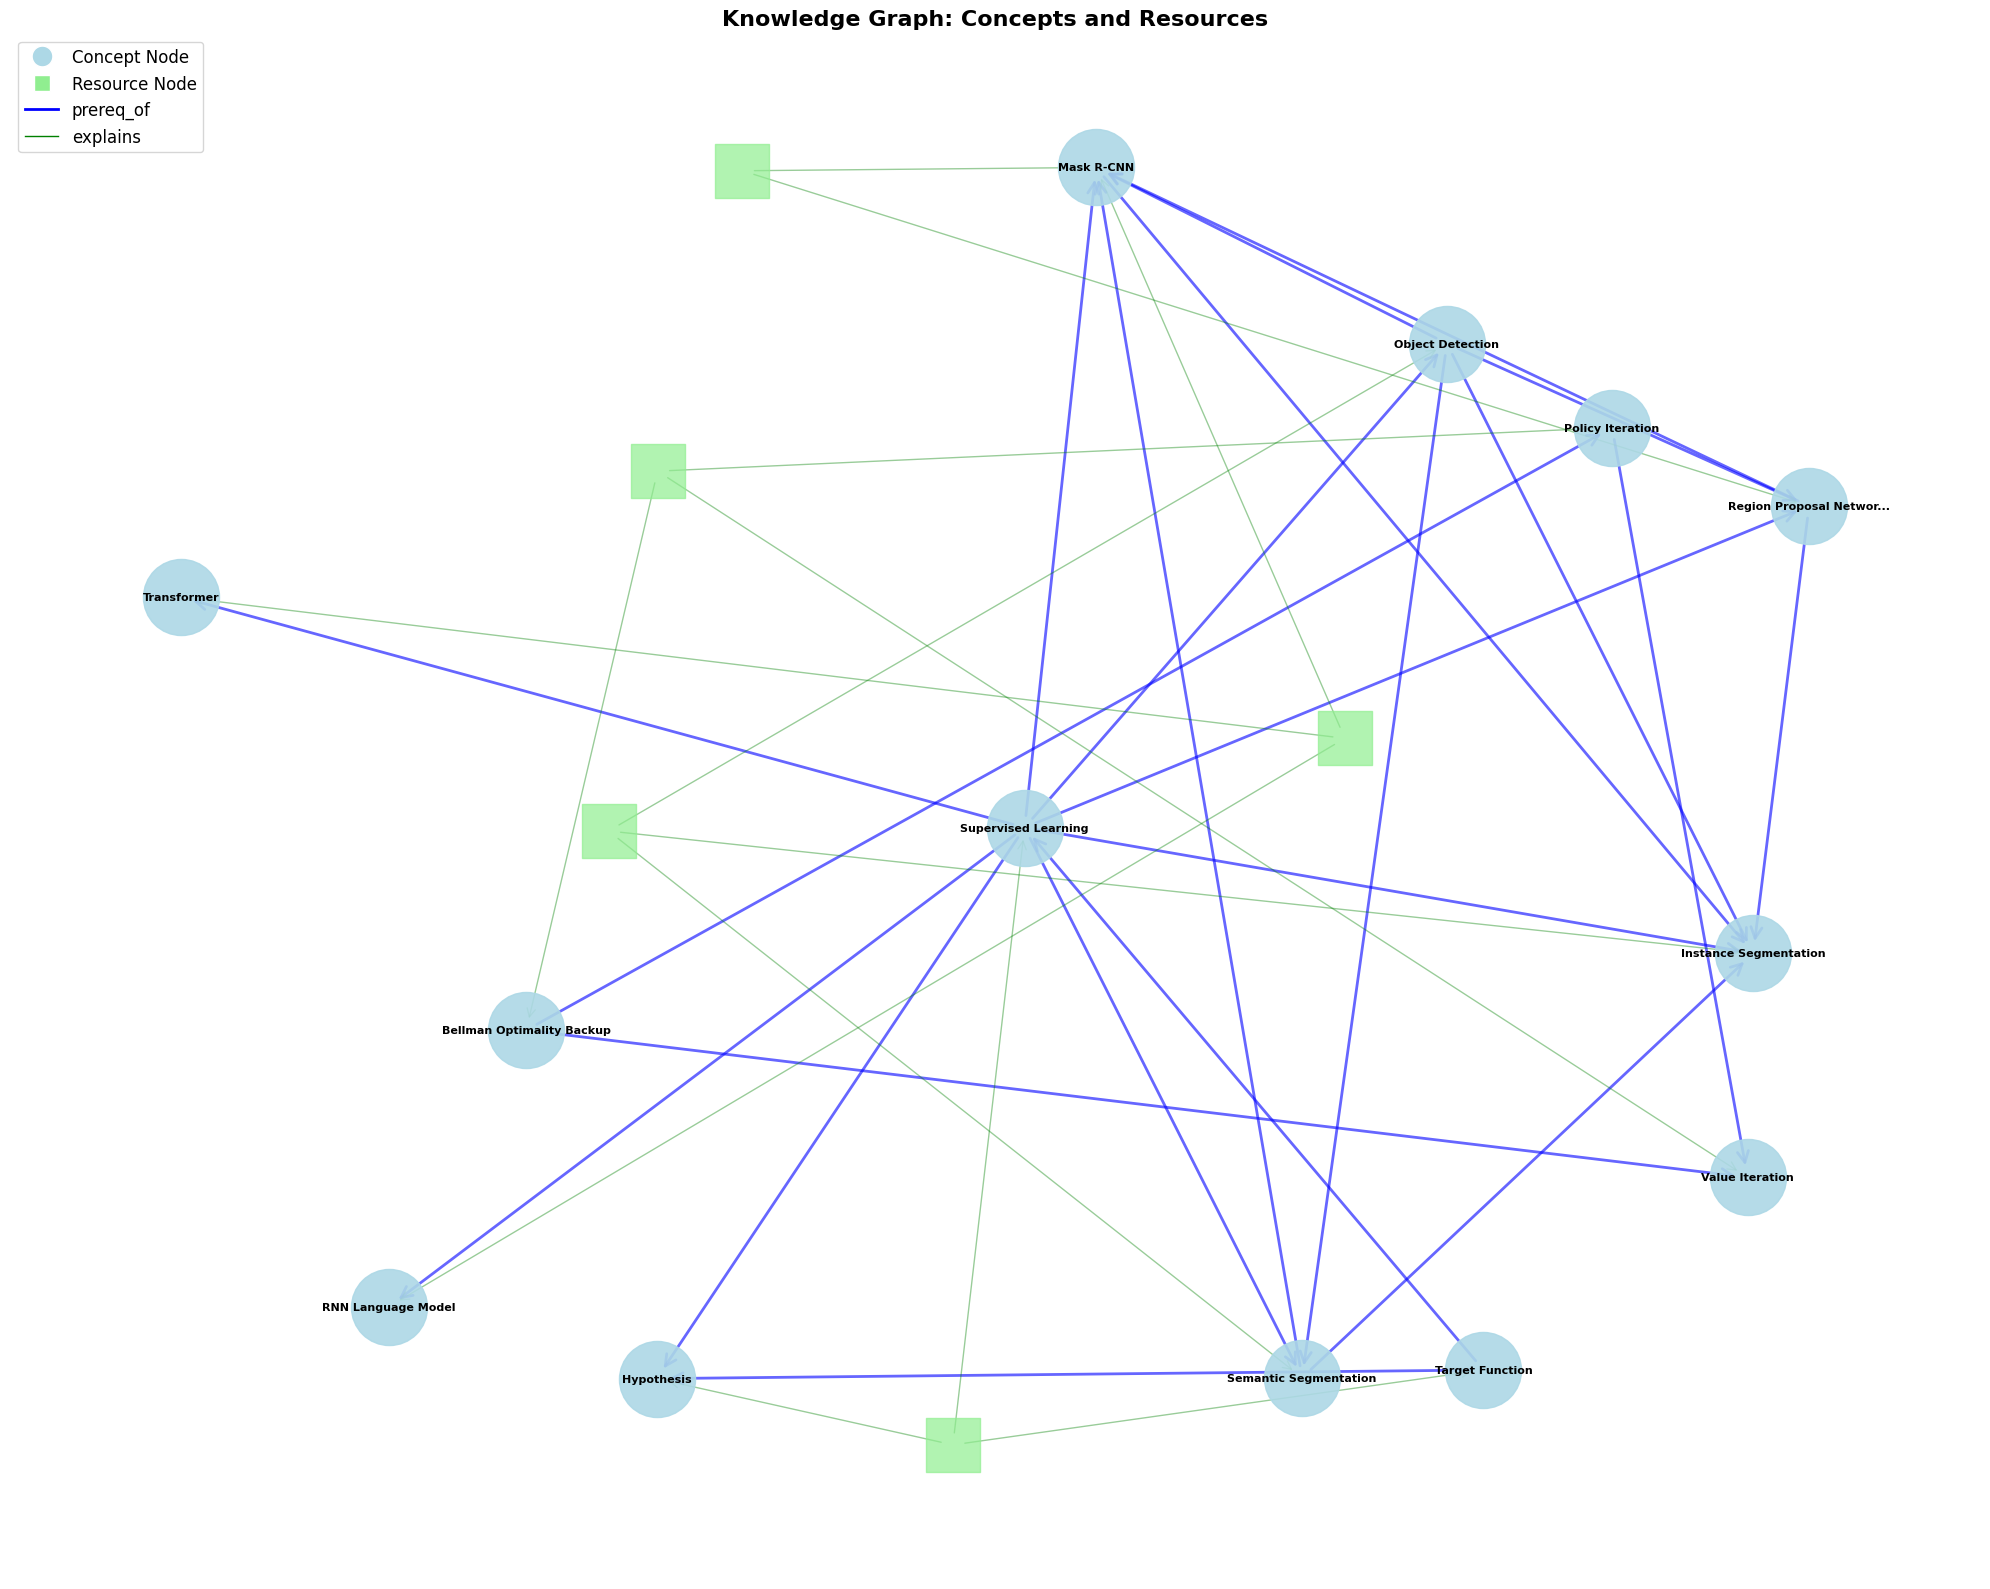


2. Concept Prerequisite Hierarchy:
Saved to /workspace/concept_prerequisite_dag.png


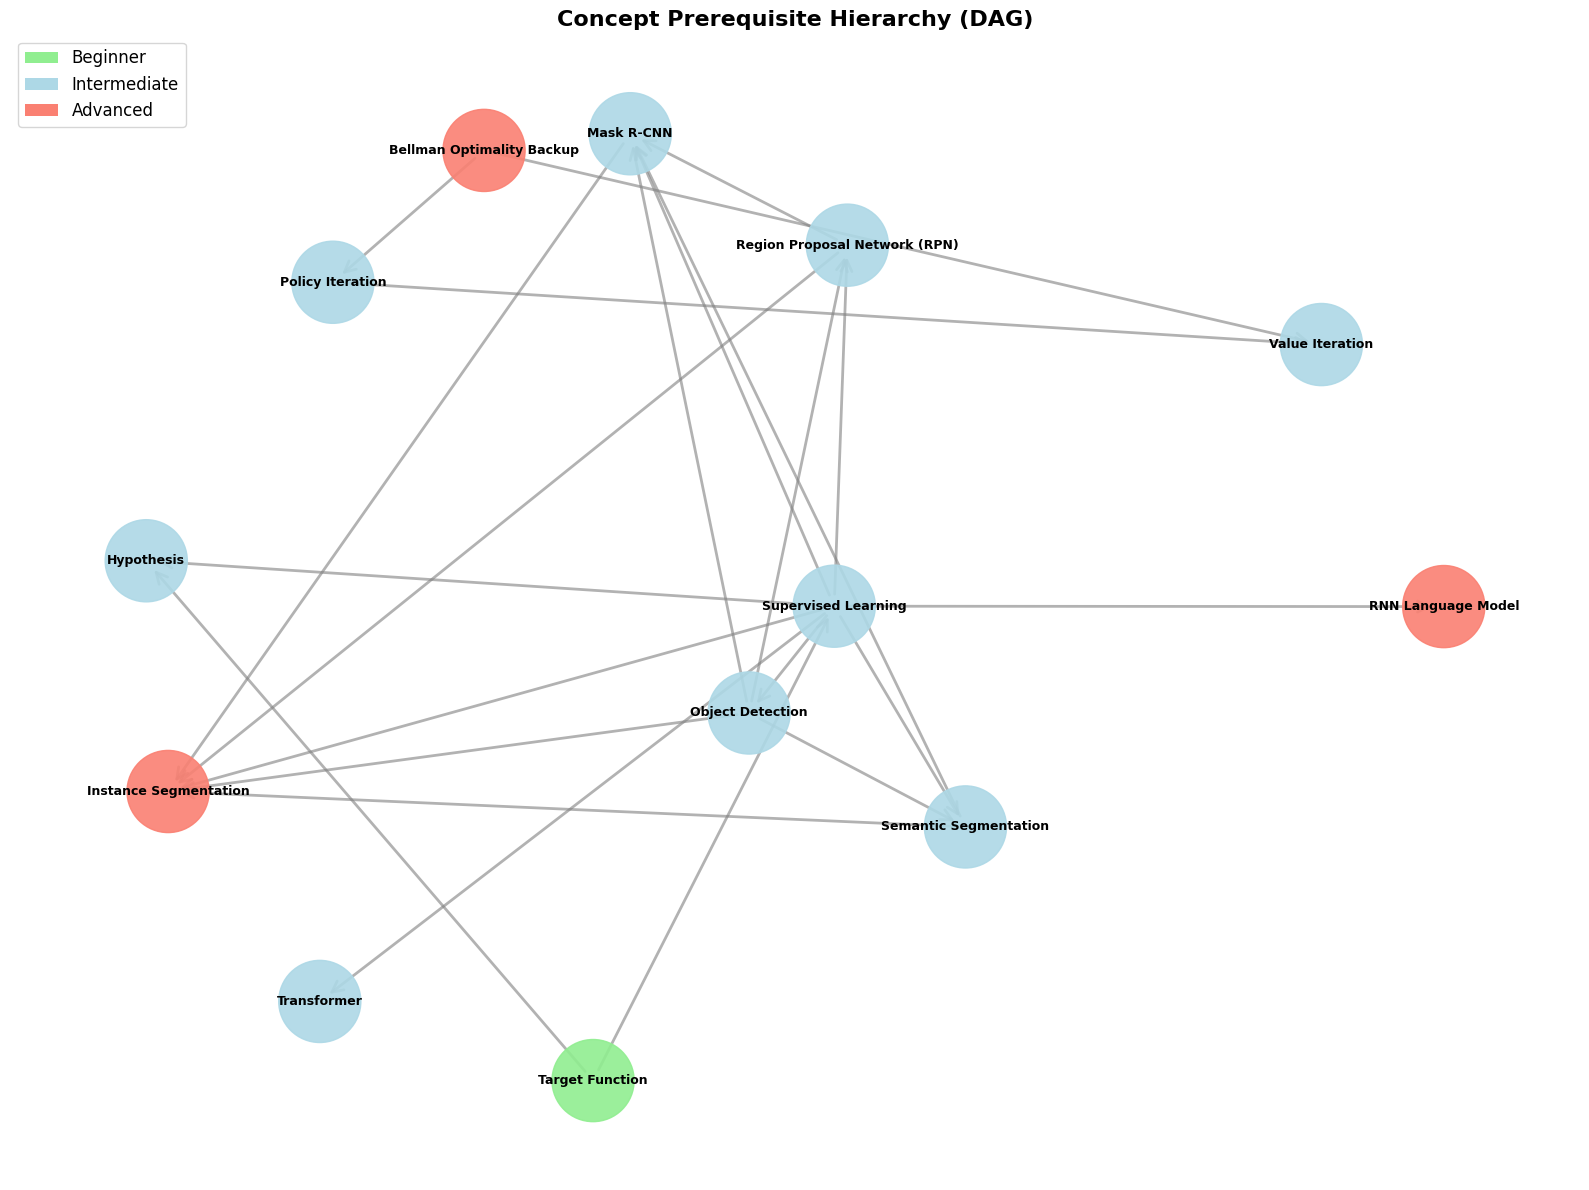


Visualization complete!


In [10]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from IPython.display import display
import os

def visualize_graph(graph, filename='knowledge_graph.png'):
    """Visualize the complete knowledge graph"""
    
    fig, ax = plt.subplots(figsize=(20, 16))
    
    # Separate nodes by type
    concept_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']
    resource_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'resource']
    
    # Use spring layout
    pos = nx.spring_layout(graph, k=2, iterations=50, seed=42)
    
    # Draw concept nodes
    nx.draw_networkx_nodes(graph, pos, 
                          nodelist=concept_nodes,
                          node_color='lightblue',
                          node_size=3000,
                          alpha=0.9,
                          node_shape='o',
                          ax=ax)
    
    # Draw resource nodes
    nx.draw_networkx_nodes(graph, pos,
                          nodelist=resource_nodes,
                          node_color='lightgreen',
                          node_size=1500,
                          alpha=0.7,
                          node_shape='s',
                          ax=ax)
    
    # Draw edges by type with different colors
    prereq_edges_list = [(u, v) for u, v, d in graph.edges(data=True) if d.get('relation') == 'prereq_of']
    explains_edges_list = [(u, v) for u, v, d in graph.edges(data=True) if d.get('relation') == 'explains']
    
    # Draw prerequisite edges (blue arrows)
    nx.draw_networkx_edges(graph, pos,
                          edgelist=prereq_edges_list,
                          edge_color='blue',
                          arrows=True,
                          arrowsize=20,
                          width=2,
                          alpha=0.6,
                          arrowstyle='->',
                          ax=ax)
    
    # Draw explains edges (green arrows)
    nx.draw_networkx_edges(graph, pos,
                          edgelist=explains_edges_list,
                          edge_color='green',
                          arrows=True,
                          arrowsize=15,
                          width=1,
                          alpha=0.4,
                          arrowstyle='->',
                          ax=ax)
    
    # Draw labels - use shortened titles for concepts
    labels = {}
    for n, d in graph.nodes(data=True):
        if d.get('node_type') == 'concept':
            title = d.get('title', n)
            # Shorten long titles
            if len(title) > 25:
                title = title[:22] + '...'
            labels[n] = title
        else:
            labels[n] = ''  # Don't label resource nodes (too cluttered)
    
    nx.draw_networkx_labels(graph, pos, labels, font_size=8, font_weight='bold', ax=ax)
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=15, label='Concept Node'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=12, label='Resource Node'),
        Line2D([0], [0], color='blue', linewidth=2, label='prereq_of'),
        Line2D([0], [0], color='green', linewidth=1, label='explains')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
    
    ax.set_title('Knowledge Graph: Concepts and Resources', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    # Save to workspace
    output_path = f'/workspace/{filename}'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {output_path}")
    
    # Display in notebook
    plt.show()


def visualize_concept_hierarchy(graph, filename='concept_hierarchy.png'):
    """Visualize just the concept prerequisite DAG"""
    
    # Extract only concepts and prerequisites
    concept_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']
    prereq_edges = [(u, v) for u, v, d in graph.edges(data=True) 
                    if d.get('relation') == 'prereq_of' and u in concept_nodes and v in concept_nodes]
    
    # Create subgraph
    concept_graph = nx.DiGraph()
    concept_graph.add_nodes_from(concept_nodes)
    concept_graph.add_edges_from(prereq_edges)
    
    # Add node attributes
    for n in concept_nodes:
        concept_graph.nodes[n]['title'] = graph.nodes[n].get('title', n)
        concept_graph.nodes[n]['difficulty'] = graph.nodes[n].get('difficulty', 'intermediate')
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Use spring layout
    pos = nx.spring_layout(concept_graph, k=3, iterations=100, seed=42)
    
    # Color by difficulty
    color_map = {
        'beginner': 'lightgreen',
        'intermediate': 'lightblue',
        'advanced': 'salmon'
    }
    
    node_colors = [color_map.get(concept_graph.nodes[n].get('difficulty', 'intermediate'), 'lightgray') 
                   for n in concept_graph.nodes()]
    
    # Draw nodes
    nx.draw_networkx_nodes(concept_graph, pos,
                          node_color=node_colors,
                          node_size=3500,
                          alpha=0.9,
                          ax=ax)
    
    # Draw edges
    nx.draw_networkx_edges(concept_graph, pos,
                          edge_color='gray',
                          arrows=True,
                          arrowsize=20,
                          width=2,
                          alpha=0.6,
                          arrowstyle='->',
                          ax=ax)
    
    # Labels
    labels = {n: concept_graph.nodes[n].get('title', n) for n in concept_graph.nodes()}
    nx.draw_networkx_labels(concept_graph, pos, labels, font_size=9, font_weight='bold', ax=ax)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightgreen', label='Beginner'),
        Patch(facecolor='lightblue', label='Intermediate'),
        Patch(facecolor='salmon', label='Advanced')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
    
    ax.set_title('Concept Prerequisite Hierarchy (DAG)', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    # Save to workspace
    output_path = f'/workspace/{filename}'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {output_path}")
    
    # Display in notebook
    plt.show()


# Generate both visualizations
print("Generating visualizations...")
print("="*60)
print("\n1. Full Knowledge Graph (Concepts + Resources):")
visualize_graph(graph, 'knowledge_graph_full.png')

print("\n2. Concept Prerequisite Hierarchy:")
visualize_concept_hierarchy(graph, 'concept_prerequisite_dag.png')

print("\n" + "="*60)
print("Visualization complete!")

## Attempt to extract all pages

In [11]:
# Process ALL pages from MongoDB
print("="*60)
print("PROCESSING ALL PAGES")
print("="*60)

# Get total count
total_pages = mongo.db.webpages.count_documents({})
print(f"Found {total_pages} pages in MongoDB\n")

# Confirm before proceeding
print(f"This will process all {total_pages} pages.")
print("Estimated time: ~{} minutes (depending on LLM speed)".format(total_pages * 2))
print("\nProcessing...")
print("="*60 + "\n")

# Fetch all pages
pages = list(mongo.db.webpages.find())

concepts_dict = {}  # concept_id -> concept_data
resources_dict = {}  # resource_id -> resource_data
concept_to_resources = defaultdict(list)  # Track which resources explain each concept

for page_num, page in enumerate(pages, 1):
    print(f"[{page_num}/{len(pages)}] {page['title'][:60]}...")
    
    # Extract concepts with chunking (processes entire document)
    concepts = extract_concepts(
        text=page['content'], 
        url=page['url'],
        chunk_id=f"page_{page_num}",
        query_ollama_func=query_ollama
    )
    
    if not concepts:
        print(f"  WARNING: No concepts extracted from this page\n")
        continue
    
    for concept in concepts:
        # Generate unique concept ID
        concept_id = concept['title'].lower().replace(' ', '_').replace('-', '_')
        
        # Add or update concept node
        if concept_id not in concepts_dict:
            concepts_dict[concept_id] = {
                'title': concept['title'],
                'difficulty': concept.get('difficulty', 'intermediate'),
                'aliases': concept.get('aliases', []),
                'definition': concept.get('definition', '')
            }
            graph.add_node(concept_id, node_type='concept', **concepts_dict[concept_id])
            print(f"  Added Concept: {concept['title']} ({concept.get('difficulty', 'intermediate')})")
        else:
            # Concept already exists, optionally merge/update definition
            existing_def = concepts_dict[concept_id]['definition']
            new_def = concept.get('definition', '')
            
            # Keep the longer definition (usually more informative)
            if len(new_def) > len(existing_def):
                concepts_dict[concept_id]['definition'] = new_def
                graph.nodes[concept_id]['definition'] = new_def
        
        # Create unique resource ID for this chunk
        chunk_id = concept.get('chunk_id', f"page_{page_num}_chunk_1")
        resource_id = f"resource_{page_num}_{chunk_id}"
        
        # Add resource node with span information
        if resource_id not in resources_dict:
            resources_dict[resource_id] = {
                'type': 'web',
                'url': page['url'],
                'title': page['title'],
                'span': chunk_id,  # M3 requirement: track which chunk/span
                'page_num': page_num
            }
            graph.add_node(resource_id, node_type='resource', **resources_dict[resource_id])
        
        # Add 'explains' edge: resource -> concept
        if not graph.has_edge(resource_id, concept_id):
            graph.add_edge(resource_id, concept_id, relation='explains')
            concept_to_resources[concept_id].append(resource_id)
    
    print()
    
    # Progress update every 10 pages
    if page_num % 10 == 0:
        print(f"\nProgress: {page_num}/{len(pages)} pages processed")
        print(f"Current stats: {len(concepts_dict)} concepts, {len(resources_dict)} resources\n")

# Summary statistics
print(f"\n{'='*60}")
print(f"EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"Extracted {len(concepts_dict)} unique concepts")
print(f"Created {len(resources_dict)} resource nodes (with spans)")
print(f"Created {graph.number_of_edges()} edges")
print(f"\nDifficulty distribution:")

# Count concepts by difficulty
difficulty_counts = defaultdict(int)
for concept_data in concepts_dict.values():
    difficulty_counts[concept_data['difficulty']] += 1

for difficulty, count in sorted(difficulty_counts.items()):
    print(f"  {difficulty}: {count} concepts")

print(f"\nTop concepts by resource coverage:")
# Show which concepts are explained by the most resources
top_concepts = sorted(concept_to_resources.items(), 
                     key=lambda x: len(x[1]), 
                     reverse=True)[:10]

for concept_id, resources in top_concepts:
    concept_title = concepts_dict[concept_id]['title']
    print(f"  {concept_title}: {len(resources)} resource chunks")

PROCESSING ALL PAGES
Found 185 pages in MongoDB

This will process all 185 pages.
Estimated time: ~370 minutes (depending on LLM speed)

Processing...

[1/185] Back2classroom – Engineering AI Agents...
  Processing 2 chunks (total text: 13,684 chars)
  Processing chunk 1/2 (8,000 chars)
    DEBUG - Raw response: [
  {"title": "Mask R-CNN", "difficulty": "intermediate", "aliases": ["Mask R-CNN"], "definition": "Extension of Faster R-CNN with mask head"},
  {"title": "LSTM", "difficulty": "intermediate", "aliases": ["Long Short-Term Memory"], "definition": "Recurrent neural network architecture"},
  {"title":
    Extracted 3 concepts from chunk 1
  Processing chunk 2/2 (6,484 chars)
    DEBUG - Raw response: [
  {"title": "Policy Iteration", "difficulty": "intermediate", "aliases": [], "definition": "Algorithm for solving MDPs by iteratively improving policies"},
  {"title": "Value Iteration", "difficulty": "intermediate", "aliases": [], "definition": "Algorithm for finding optimal state

In [12]:
# Print all extracted concepts
print(f"\n{'='*60}")
print(f"ALL EXTRACTED CONCEPTS")
print(f"{'='*60}")
print(f"Total: {len(concepts_dict)} concepts\n")

# Sort concepts alphabetically by title
sorted_concepts = sorted(concepts_dict.items(), key=lambda x: x[1]['title'])

for idx, (concept_id, concept_data) in enumerate(sorted_concepts, 1):
    print(f"{idx:3d}. {concept_data['title']}")
    print(f"     ID: {concept_id}")
    print(f"     Difficulty: {concept_data['difficulty']}")
    
    if concept_data.get('aliases'):
        print(f"     Aliases: {', '.join(concept_data['aliases'])}")
    
    # Show definition preview (first 100 chars)
    definition = concept_data.get('definition', '')
    if definition:
        definition_preview = definition[:100] + "..." if len(definition) > 100 else definition
        print(f"     Definition: {definition_preview}")
    
    # Show how many resources explain this concept
    num_resources = len(concept_to_resources.get(concept_id, []))
    print(f"     Explained by: {num_resources} resource(s)")
    print()

# Optional: Group by difficulty level
print(f"\n{'='*60}")
print(f"CONCEPTS GROUPED BY DIFFICULTY")
print(f"{'='*60}")

for difficulty in ['beginner', 'intermediate', 'advanced']:
    concepts_at_level = [(cid, cdata) for cid, cdata in concepts_dict.items() 
                         if cdata['difficulty'] == difficulty]
    
    if concepts_at_level:
        print(f"\n{difficulty.upper()} ({len(concepts_at_level)} concepts):")
        for concept_id, concept_data in sorted(concepts_at_level, key=lambda x: x[1]['title']):
            print(f"  - {concept_data['title']}")


ALL EXTRACTED CONCEPTS
Total: 311 concepts

  1. 1x1 Convolutional Layer
     ID: 1x1_convolutional_layer
     Difficulty: advanced
     Definition: Layer used for feature map manipulation and dimensionality reduction
     Explained by: 1 resource(s)

  2. Activation Function
     ID: activation_function
     Difficulty: beginner
     Definition: Function applied to layer outputs, e.g., ReLU
     Explained by: 1 resource(s)

  3. Activation Visualization
     ID: activation_visualization
     Difficulty: intermediate
     Definition: Technique to understand how convnets process inputs
     Explained by: 1 resource(s)

  4. Adam Optimizer
     ID: adam_optimizer
     Difficulty: intermediate
     Definition: Optimization algorithm that adapts learning rates for each parameter
     Explained by: 2 resource(s)

  5. Alignment
     ID: alignment
     Difficulty: advanced
     Definition: Property of embeddings where positive pairs map to the same point in embedding space
     Explained by

Generating visualizations...

1. Full Knowledge Graph (Concepts + Resources):
Saved to /workspace/knowledge_graph_full.png


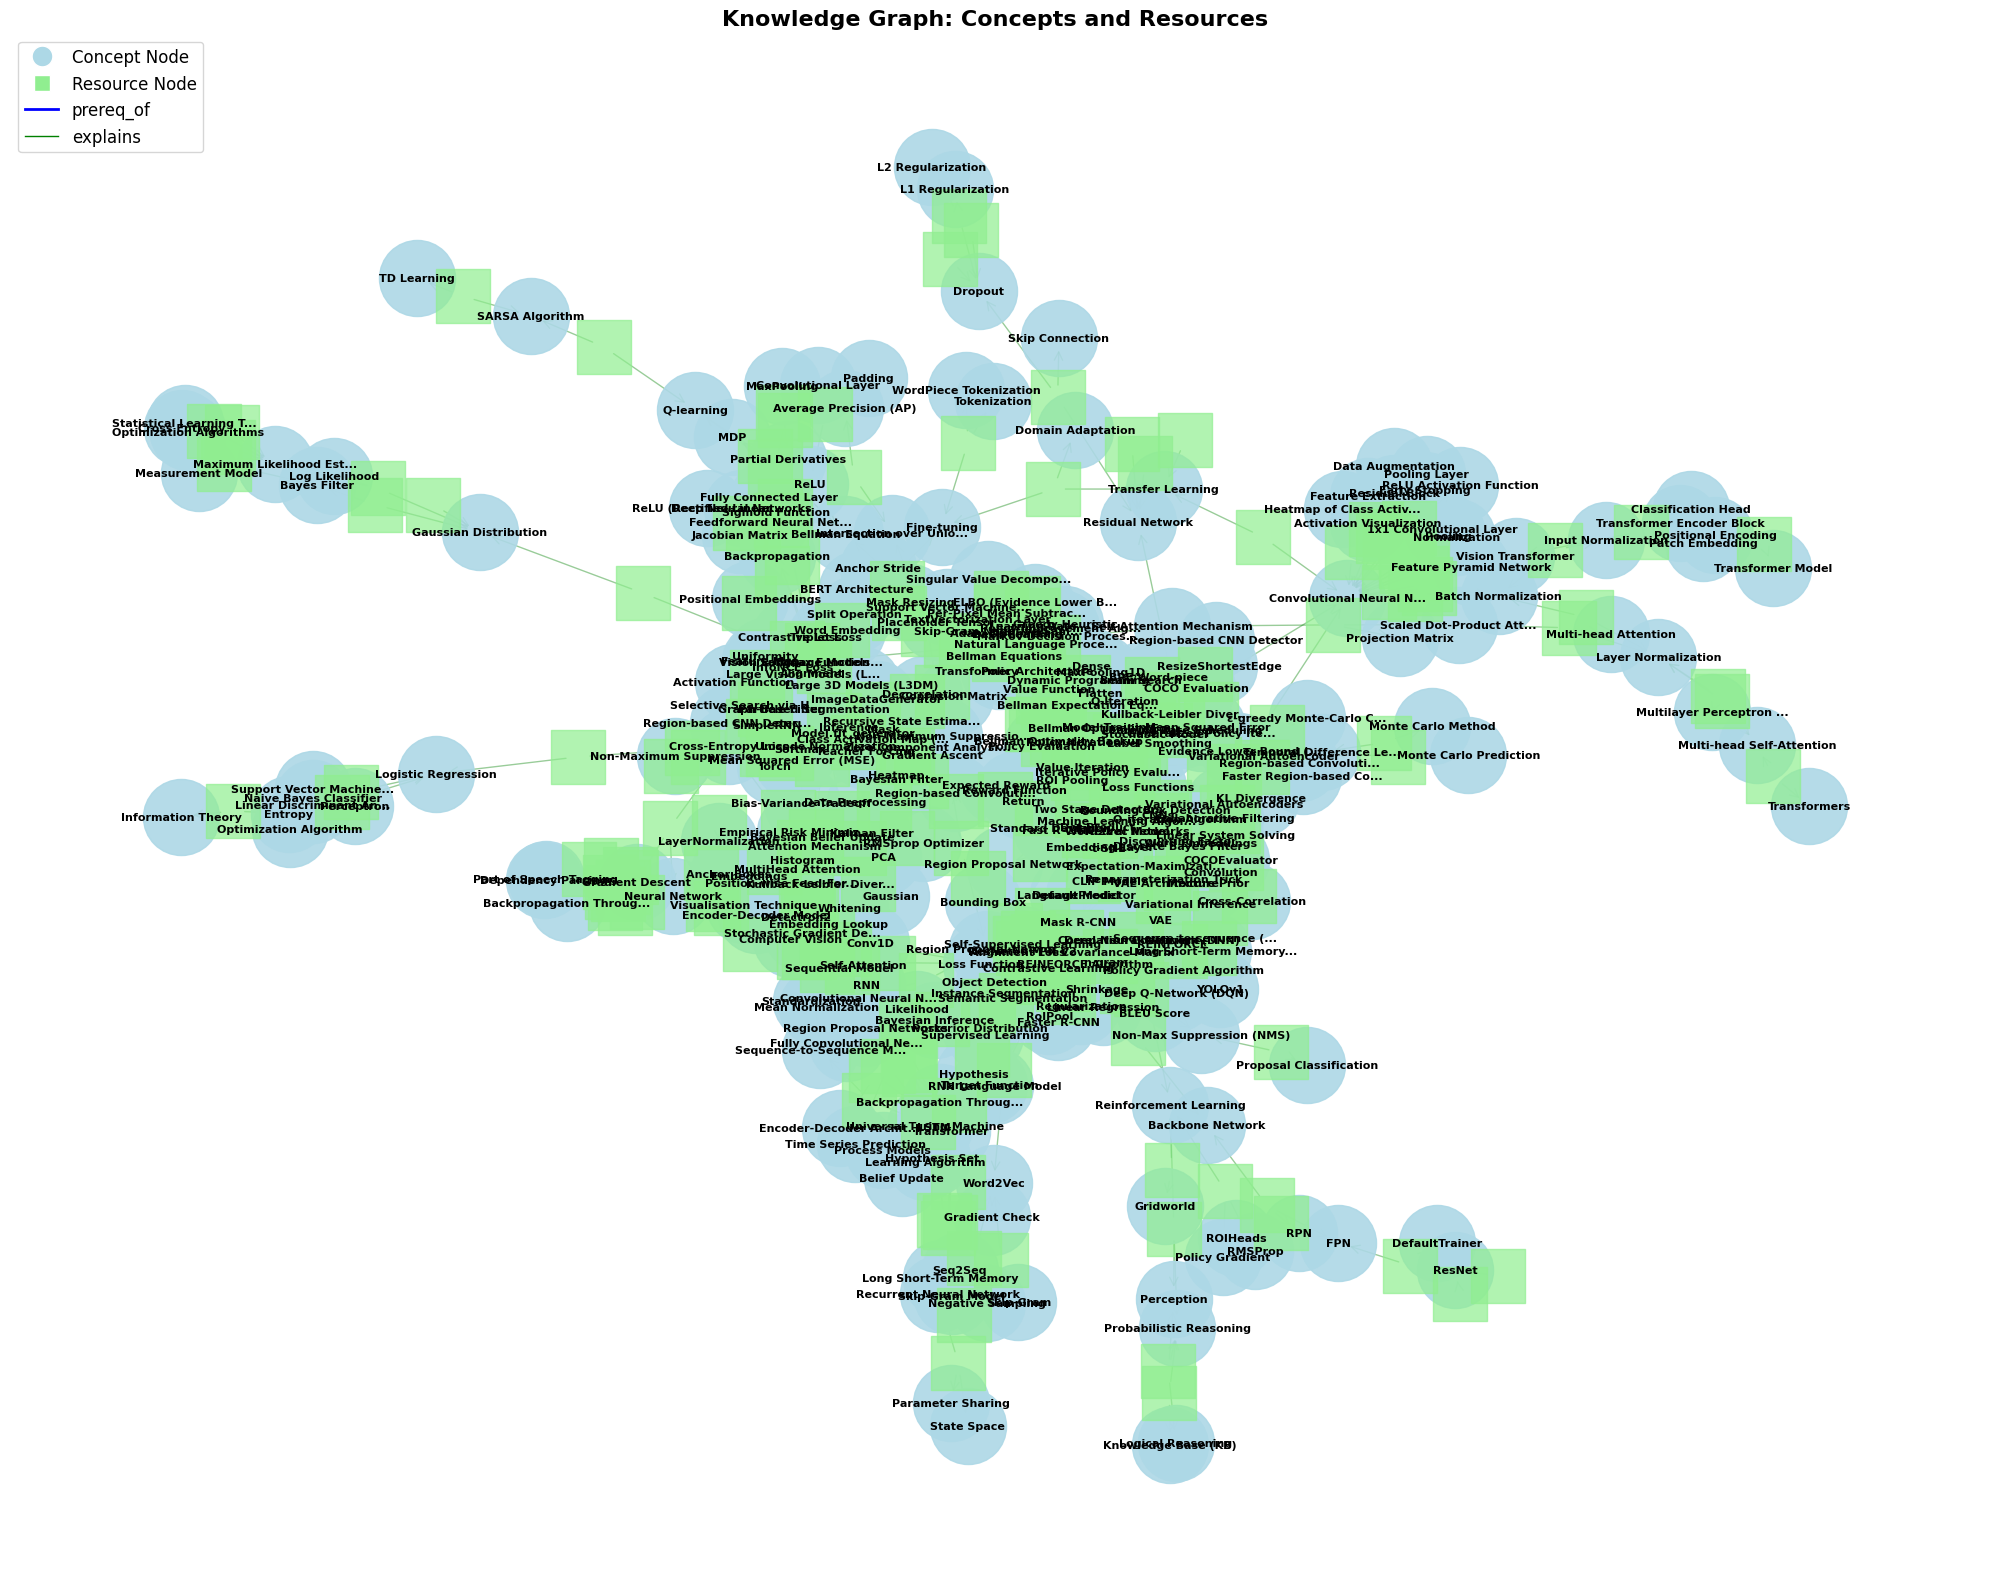


2. Concept Prerequisite Hierarchy:
Saved to /workspace/concept_prerequisite_dag.png


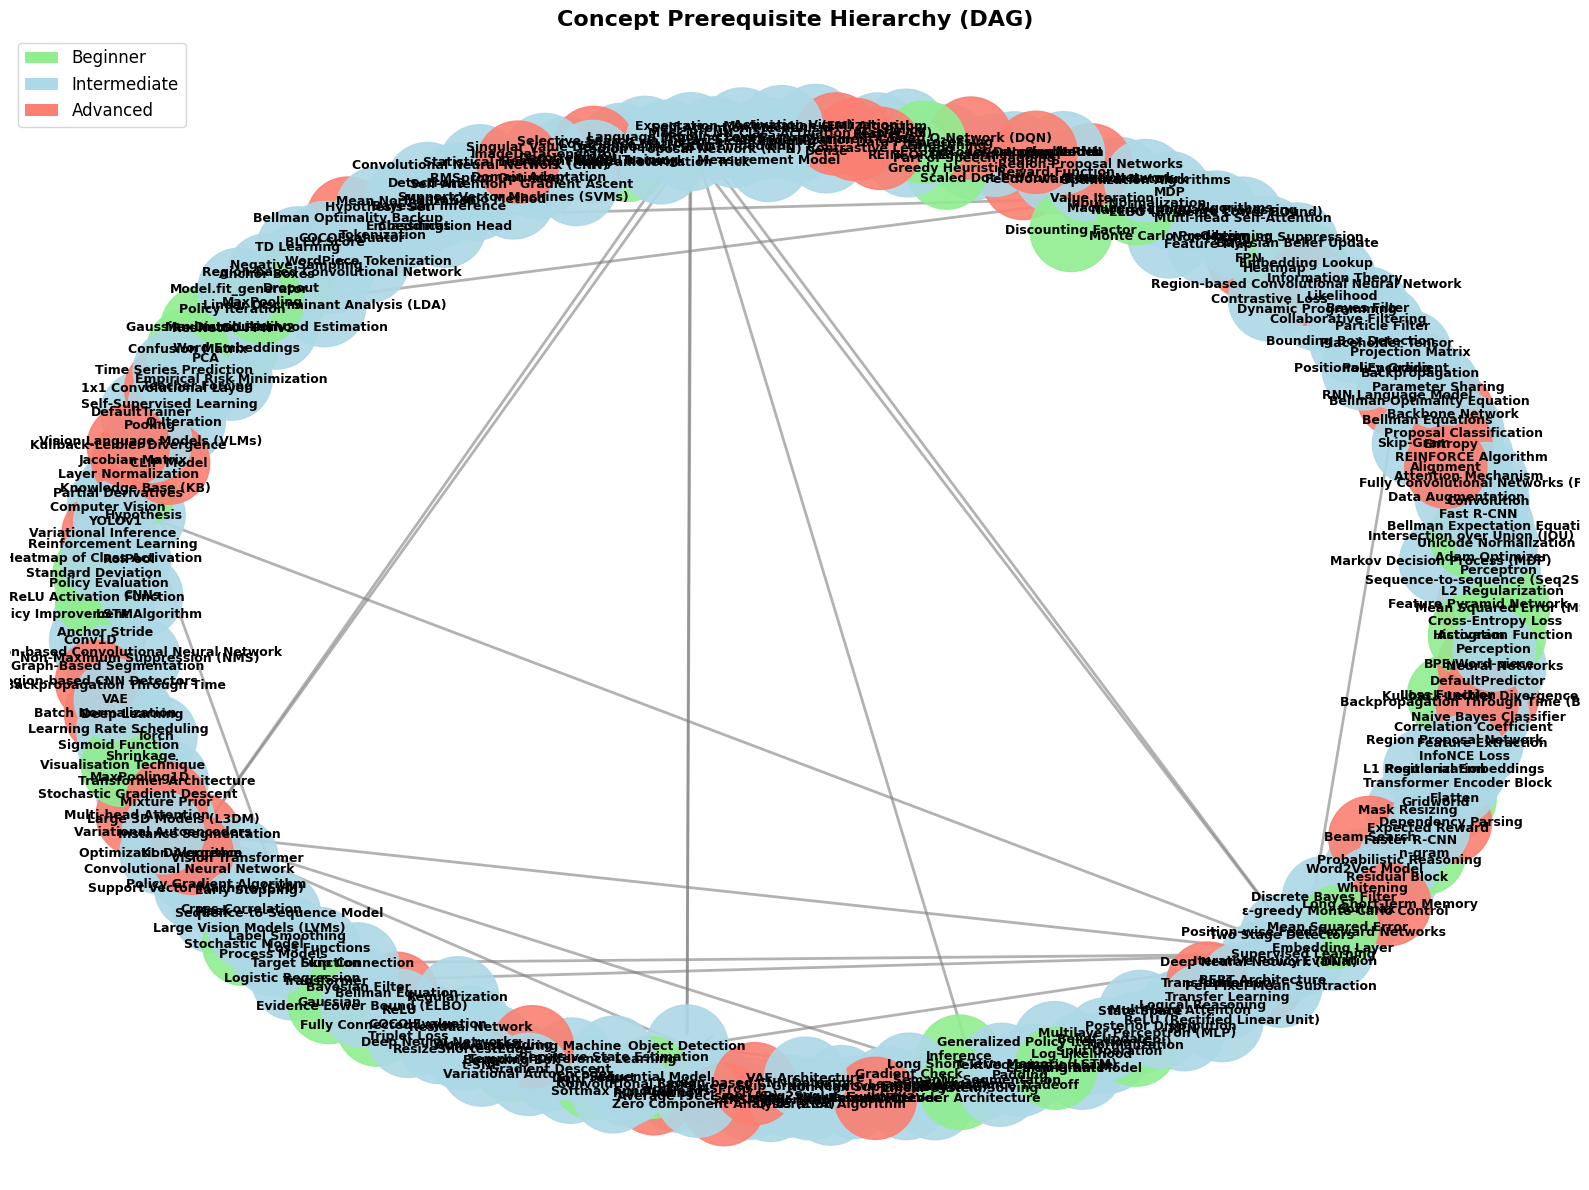


Visualization complete!


In [13]:
# Generate both visualizations
print("Generating visualizations...")
print("="*60)
print("\n1. Full Knowledge Graph (Concepts + Resources):")
visualize_graph(graph, 'knowledge_graph_full.png')

print("\n2. Concept Prerequisite Hierarchy:")
visualize_concept_hierarchy(graph, 'concept_prerequisite_dag.png')

print("\n" + "="*60)
print("Visualization complete!")

In [14]:

# Save the graph using pickle directly
import pickle

with open('/workspace/knowledge_graph.pkl', 'wb') as f:
    pickle.dump(graph, f)

print("Graph saved successfully!")

Graph saved successfully!
